In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [59]:
df = pd.read_csv("../data/course_lead_scoring_2026.csv")
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


Data preparation

In [60]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [61]:
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(0.0)

cat_cols = df.select_dtypes(include=["str"]).columns
df[cat_cols] = df[cat_cols].fillna("NA")

df.head(10)

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NA,0.0,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1
5,referral,manufacturing,employed,africa,43841.0,3,5,0.77,1
6,NA,education,employed,north_america,58738.0,3,9,0.78,1
7,paid_ads,technology,employed,north_america,95059.0,2,4,0.41,1
8,organic_search,healthcare,employed,asia,62565.0,3,6,0.52,1
9,referral,retail,student,asia,12000.0,2,2,0.35,0


In [62]:
from sklearn.model_selection import train_test_split

In [63]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values
del df_train["converted"]
del df_val["converted"]
del df_test["converted"]

Question 1: ROC AUC feature importance

In [64]:
from sklearn.metrics import roc_auc_score

In [65]:
scores = {}
n_cols = list(num_cols)
n_cols.remove("converted")
for n in n_cols:
    score = roc_auc_score(y_train, df_train[n])
    if score < 0.5:
        score = roc_auc_score(y_train, -df_train[n])
    scores[n] = score 
best_col = max(scores, key=scores.get)
print(f"{best_col}: {scores[best_col]}")

lead_score: 0.7882254810906102


Question 2: Training the model

OHE

In [66]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

features = list(cat_cols) + list(num_cols)
features.remove("converted")
train_dict = df_train[features].to_dict(orient="records")
X_train = dv.fit_transform(train_dict)

val_dict = df_val[features].to_dict(orient="records")
X_val = dv.transform(val_dict)

Training model

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]
round(roc_auc_score(y_val, y_pred), 3)

0.732

Question 3: Precision and Recall

In [68]:
thresholds = np.linspace(0, 1, 101)
precisions = []
recalls = []
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    if (tp + fp) == 0:
        precisions.append(1.0)
    else:
        precisions.append(tp / (tp + fp))

    if (tp + fn) == 0:
        recalls.append(0.0)
    else:
        recalls.append(tp / (tp + fn))


Text(0, 0.5, 'Score')

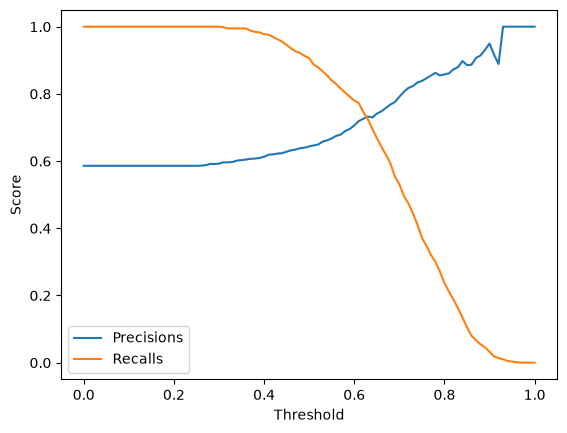

In [74]:
plt.plot(thresholds, precisions, label="Precisions")
plt.plot(thresholds, recalls, label="Recalls")
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")


In [75]:
precisions_arr = np.array(precisions)
recalls_arr = np.array(recalls)

idx = np.argmin(np.abs(precisions_arr - recalls_arr))

best_threshold = thresholds[idx]

print(best_threshold)

0.63


In [83]:
thresholds = np.linspace(0, 1, 101)
F1 = {}
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    if (tp + fp) == 0:
        p = 1.0
    else:
        p = tp / (tp + fp)

    if (tp + fn) == 0:
        r = 0.0
    else:
        r = tp / (tp + fn) 
    F1[t] = 2*(p * r / (p + r))

best_t = max(F1, key=F1.get)
print(f"{best_t:.2f}: {F1[best_t]}")


0.41: 0.7576158940397352


Question 5: 5-Fold CV

In [85]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
features = list(cat_cols) + list(num_cols)
features.remove("converted")
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values


    dicts = df_train[features].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)

    dicts = df_val[features].to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]
    scores.append(roc_auc_score(y_val, y_pred))

print(f'{np.mean(scores):.3f} +- {np.std(scores):.3f}')

0.732 +- 0.007


Question 6: Hyperparameter Tuning

In [88]:
from sklearn.model_selection import KFold
from tqdm.auto import tqdm

features = list(cat_cols) + list(num_cols)
features.remove("converted")

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values


        dicts = df_train[features].to_dict(orient='records')

        dv = DictVectorizer(sparse=False)
        X_train = dv.fit_transform(dicts)

        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train, y_train)

        dicts = df_val[features].to_dict(orient='records')
        X = dv.transform(dicts)
        y_pred = model.predict_proba(X)[:, 1]
        scores.append(roc_auc_score(y_val, y_pred))

    print(f'C={C} {np.mean(scores):.3f} +- {np.std(scores):.3f}')

  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06 0.617 +- 0.019
C=0.001 0.749 +- 0.010
C=1 0.732 +- 0.007
